# 05 · Predictions

The payoff notebook. Using the honest walk-forward design from notebook 04, I answer three questions:

1. **Full vs retail model** — how much accuracy does a retail investor lose by deciding *during* the
   bidding window instead of waiting for the final subscription book?
2. **Does the model beat just trusting GMP?** — GMP is a free prediction; the model has to earn its
   keep against it.
3. A final picture: predicted vs actual across 2025–26.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

PROC = "../data/processed"
target = "listing_gain_close_pct"

df = pd.read_csv(f"{PROC}/ipo_features.csv", parse_dates=["list_date"])
df_time = df.sort_values("list_date").reset_index(drop=True)
start = (df_time["year"] <= 2024).sum()
actual = df_time.iloc[start:][target].values

features = [c for c in df.columns if c not in ["company", "year", "list_date", target]]


In [2]:
# same honest walk-forward as notebook 04, reused here
def walk_forward(feature_cols):
    preds = []
    i = start
    while i < len(df_time):
        train = df_time.iloc[:i]
        test  = df_time.iloc[i:i + 5]
        lo, hi = train[target].quantile([0.02, 0.98])
        y_clip = train[target].clip(lo, hi)

        gb = GradientBoostingRegressor(n_estimators=200, max_depth=1,
                                       learning_rate=0.05, loss="absolute_error", random_state=42).fit(train[feature_cols], y_clip)
        rf = RandomForestRegressor(n_estimators=300, max_depth=3, random_state=42).fit(train[feature_cols], y_clip)
        preds.extend((gb.predict(test[feature_cols]) + rf.predict(test[feature_cols])) / 2)
        i += 5
    return np.array(preds)


## 1. Full model vs retail model

The **full model** uses the final subscription numbers — but those are published only *after* the IPO
closes. A real **retail investor decides on bidding day 3**, when only day-1/day-2 subscription and
GMP up to day 3 are visible. So I build a retail version on just that information and compare both on
the same honest test.


In [3]:
retail_features = ["issue_size_cr", "sub_day1_x", "sub_day2_x",
                   "gmp_day1_pct", "gmp_day2_pct", "gmp_day3_pct",
                   "nifty_ret_5d", "nifty_ret_1m", "nifty_drawdown"]

full_pred   = walk_forward(features)
retail_pred = walk_forward(retail_features)

pd.DataFrame({
    "R2":  [r2_score(actual, full_pred),  r2_score(actual, retail_pred)],
    "MAE": [mean_absolute_error(actual, full_pred), mean_absolute_error(actual, retail_pred)],
}, index=["Full model (sees final subscription)", "Retail model (only bid-day-3 info)"]).round(3)


,R2,MAE
Full model (sees final subscription),0.499,11.107
Retail model (only bid-day-3 info),0.455,11.889


The retail model is only slightly behind. **The practical takeaway:** an investor deciding early,
with only public day-3 information, can predict the listing almost as well as one who waits for the
full book — most of the signal is already visible while you can still apply.


## 2. Does the model beat just trusting GMP?

GMP day-3, used directly as the prediction, is a free baseline that needs no model. The model must
beat it. I compare them on the same test IPOs, looking at R², the average bias, and the correlation.


In [4]:
gmp3 = df_time.iloc[start:]["gmp_day3_pct"].values

def report(name, pred):
    print(f"{name}")
    print(f"   R2   : {r2_score(actual, pred):.3f}")
    print(f"   MAE  : {mean_absolute_error(actual, pred):.2f}")
    print(f"   bias : {pred.mean() - actual.mean():+.1f}   (how much it over-predicts on average)")
    print(f"   corr : {np.corrcoef(pred, actual)[0, 1]:.2f}")

report("GMP day-3 only (no model)", gmp3)
print()
report("Full model", full_pred)


GMP day-3 only (no model)
   R2   : 0.003
   MAE  : 13.85
   bias : +6.7   (how much it over-predicts on average)
   corr : 0.52

Full model
   R2   : 0.499
   MAE  : 11.11
   bias : +3.4   (how much it over-predicts on average)
   corr : 0.72


**The interesting result.** Raw GMP has an R² near **0** but a correlation around **0.5** — so it
clearly carries signal, it is just *miscalibrated*. In the cooled market the grey market kept quoting
hot-market premiums, so GMP over-predicts by several points. The model keeps GMP's direction but
**fixes its scale** using market mood and constant retraining — so its bias shrinks, its correlation
rises, and its R² jumps to ~0.50. In one line: **GMP has the signal; the model fixes the scale.**


## 3. Final picture — predicted vs actual (2025–26)

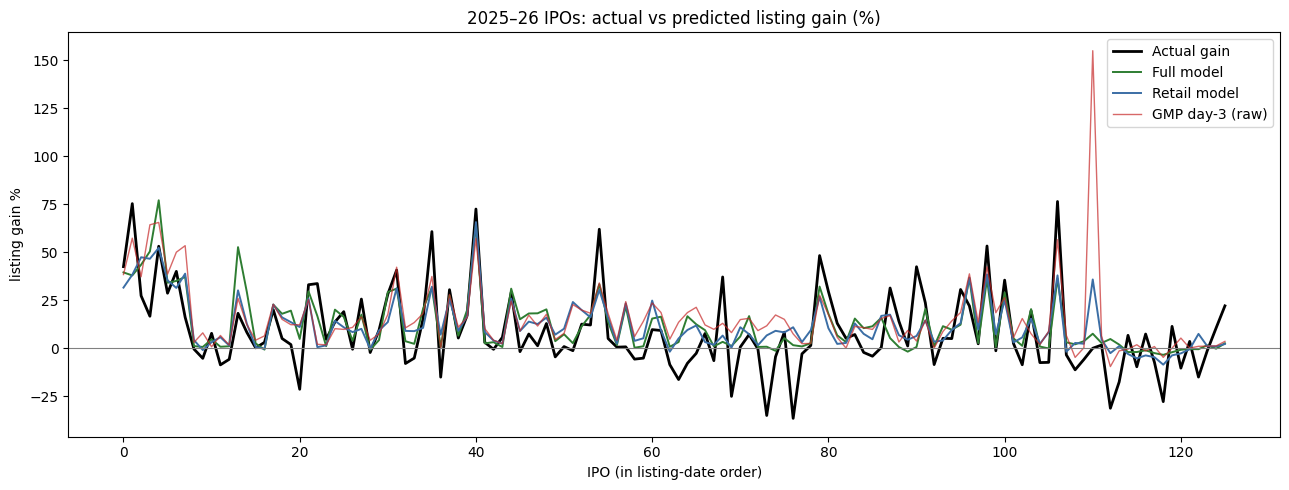

In [5]:
order = np.arange(len(actual))

plt.figure(figsize=(13, 5))
plt.plot(order, actual,      label="Actual gain",     color="black",   lw=2)
plt.plot(order, full_pred,   label="Full model",      color="#2e7d32", lw=1.4)
plt.plot(order, retail_pred, label="Retail model",    color="#3b6ea5", lw=1.4)
plt.plot(order, gmp3,        label="GMP day-3 (raw)",  color="#c62828", lw=1.0, alpha=0.7)
plt.axhline(0, color="gray", lw=0.8)
plt.title("2025–26 IPOs: actual vs predicted listing gain (%)")
plt.xlabel("IPO (in listing-date order)"); plt.ylabel("listing gain %")
plt.legend(); plt.tight_layout(); plt.show()


You can see the story: raw **GMP (red) sits consistently above the actual (black)** — that is the
over-prediction bias. The **model lines hug the actual much more closely**, because they re-scale GMP
to the cooled market.

## Conclusion

- **GMP is the strongest signal**, but raw GMP is miscalibrated in a cooled market — the model's job
  is to fix its scale, not to invent new information.
- A naive random-split model looks great (R² ~0.55) but is **misleading**, because the IPO market
  cooled sharply after 2024.
- The honest evaluation is **walk-forward** — train on the past, predict the future, retrain as new
  IPOs arrive. The leak-free score is about **R² 0.50** with a healthy train–test gap.
- The **retail model**, using only bidding-day-3 information, performs almost as well as the full
  model — the actionable version barely trails the academic one.

The main lesson: on a near-efficient market, **honest validation design matters more than the
headline accuracy number.**
